# Housing Prices Competition for Kaggle Learn Users

In [1]:
import warnings
warnings.filterwarnings("ignore")
 
import numpy as np
import pandas as pd
 
import matplotlib.pyplot as plt
import seaborn as sns
 
from scipy import stats
from scipy.stats import skew, norm
 
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.metrics import mean_squared_error
 
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
 
try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
 
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 100)
 
RANDOM_STATE = 42
 

In [2]:
DATA_DIR = "./data"
 
train = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")
 
print("Train shape:", train.shape)
print("Test shape :", test.shape)
 
train.head()
 
 

Train shape: (1460, 81)
Test shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
train_ID = train["Id"]
test_ID = test["Id"]
 
train.drop("Id", axis=1, inplace=True)
test.drop("Id", axis=1, inplace=True)
 
train.describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0


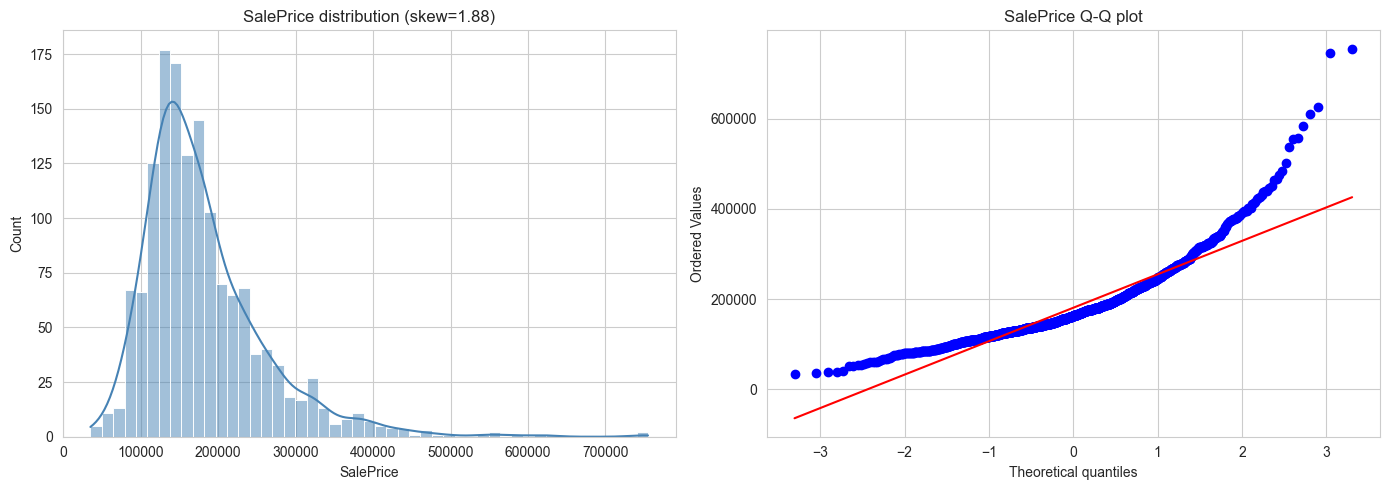

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
sns.histplot(train["SalePrice"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title(f"SalePrice distribution (skew={skew(train['SalePrice']):.2f})")
 
stats.probplot(train["SalePrice"], plot=axes[1])
axes[1].set_title("SalePrice Q-Q plot")
 
plt.tight_layout()
plt.show()

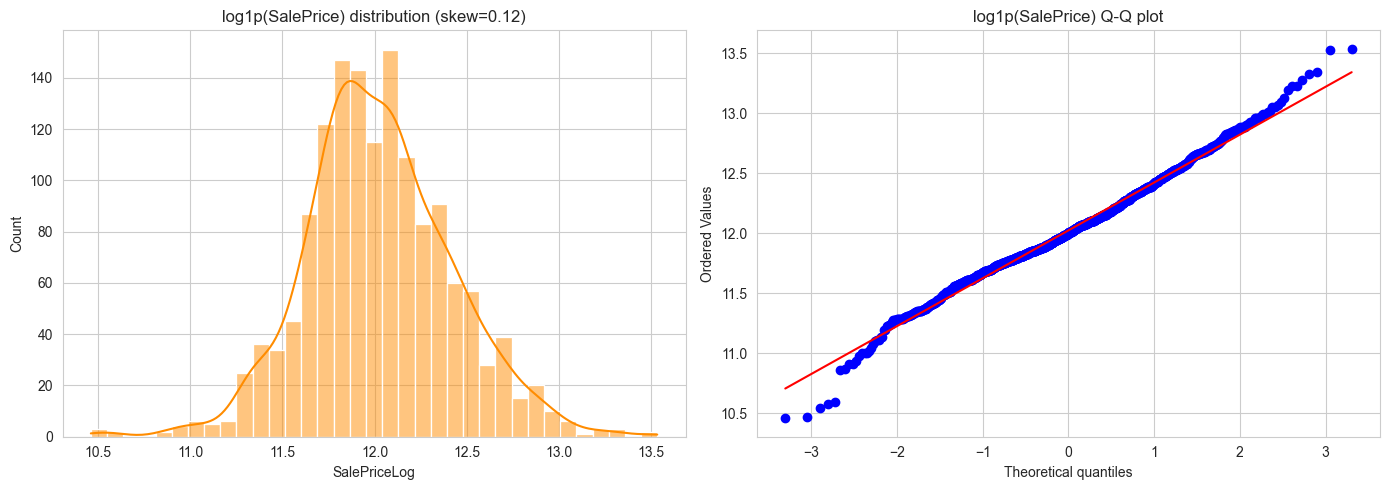

In [5]:
train["SalePriceLog"] = np.log1p(train["SalePrice"])
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
sns.histplot(train["SalePriceLog"], kde=True, ax=axes[0], color="darkorange")
axes[0].set_title(f"log1p(SalePrice) distribution (skew={skew(train['SalePriceLog']):.2f})")
 
stats.probplot(train["SalePriceLog"], plot=axes[1])
axes[1].set_title("log1p(SalePrice) Q-Q plot")
 
plt.tight_layout()
plt.show()

In [6]:
def missing_table(df):
    total = df.isnull().sum()
    pct = (total / len(df)) * 100
    tbl = pd.concat([total, pct], axis=1, keys=["Total", "Percent"])
    return tbl[tbl["Total"] > 0].sort_values("Percent", ascending=False)
 
missing_train = missing_table(train)
missing_train

,Total,Percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


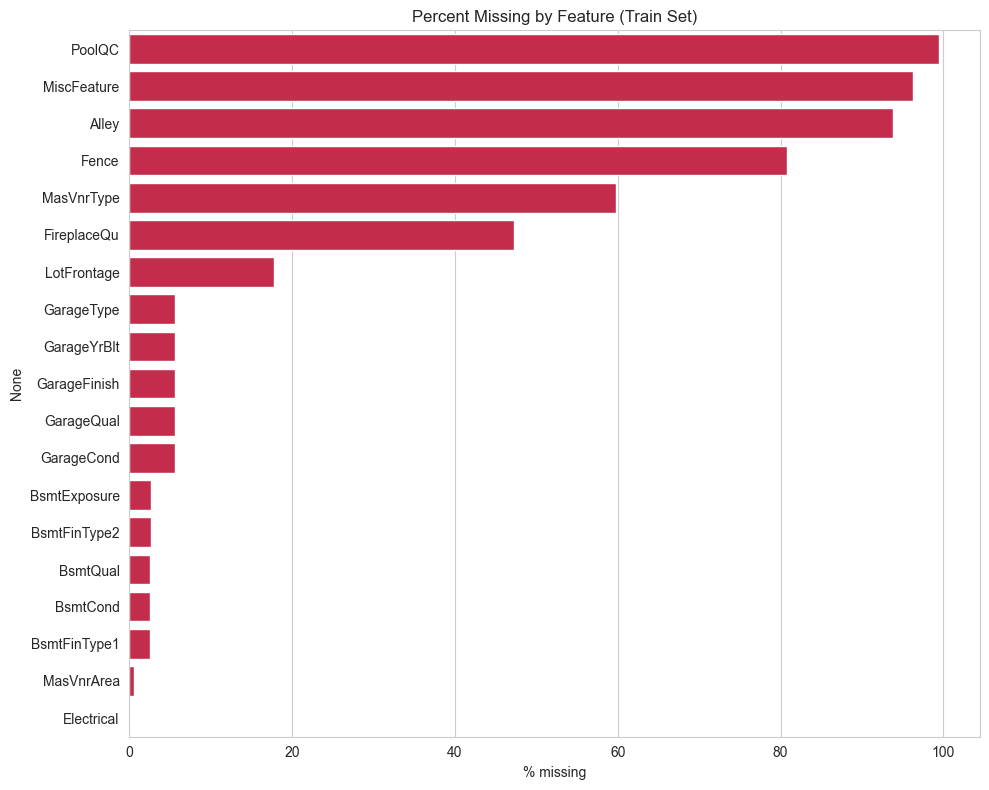

In [7]:
plt.figure(figsize=(10, 8))
sns.barplot(x=missing_train["Percent"], y=missing_train.index, color="crimson")
plt.title("Percent Missing by Feature (Train Set)")
plt.xlabel("% missing")
plt.tight_layout()
plt.show()

In [8]:
numeric_feats = train.select_dtypes(include=[np.number]).columns.tolist()
numeric_feats = [c for c in numeric_feats if c not in ("SalePrice", "SalePriceLog")]
 
corr_with_target = train[numeric_feats + ["SalePrice"]].corr()["SalePrice"].drop("SalePrice")
top_corr_feats = corr_with_target.abs().sort_values(ascending=False).head(9).index.tolist()
top_corr_feats

['OverallQual',
 'GrLivArea',
 'GarageCars',
 'GarageArea',
 'TotalBsmtSF',
 '1stFlrSF',
 'FullBath',
 'TotRmsAbvGrd',
 'YearBuilt']

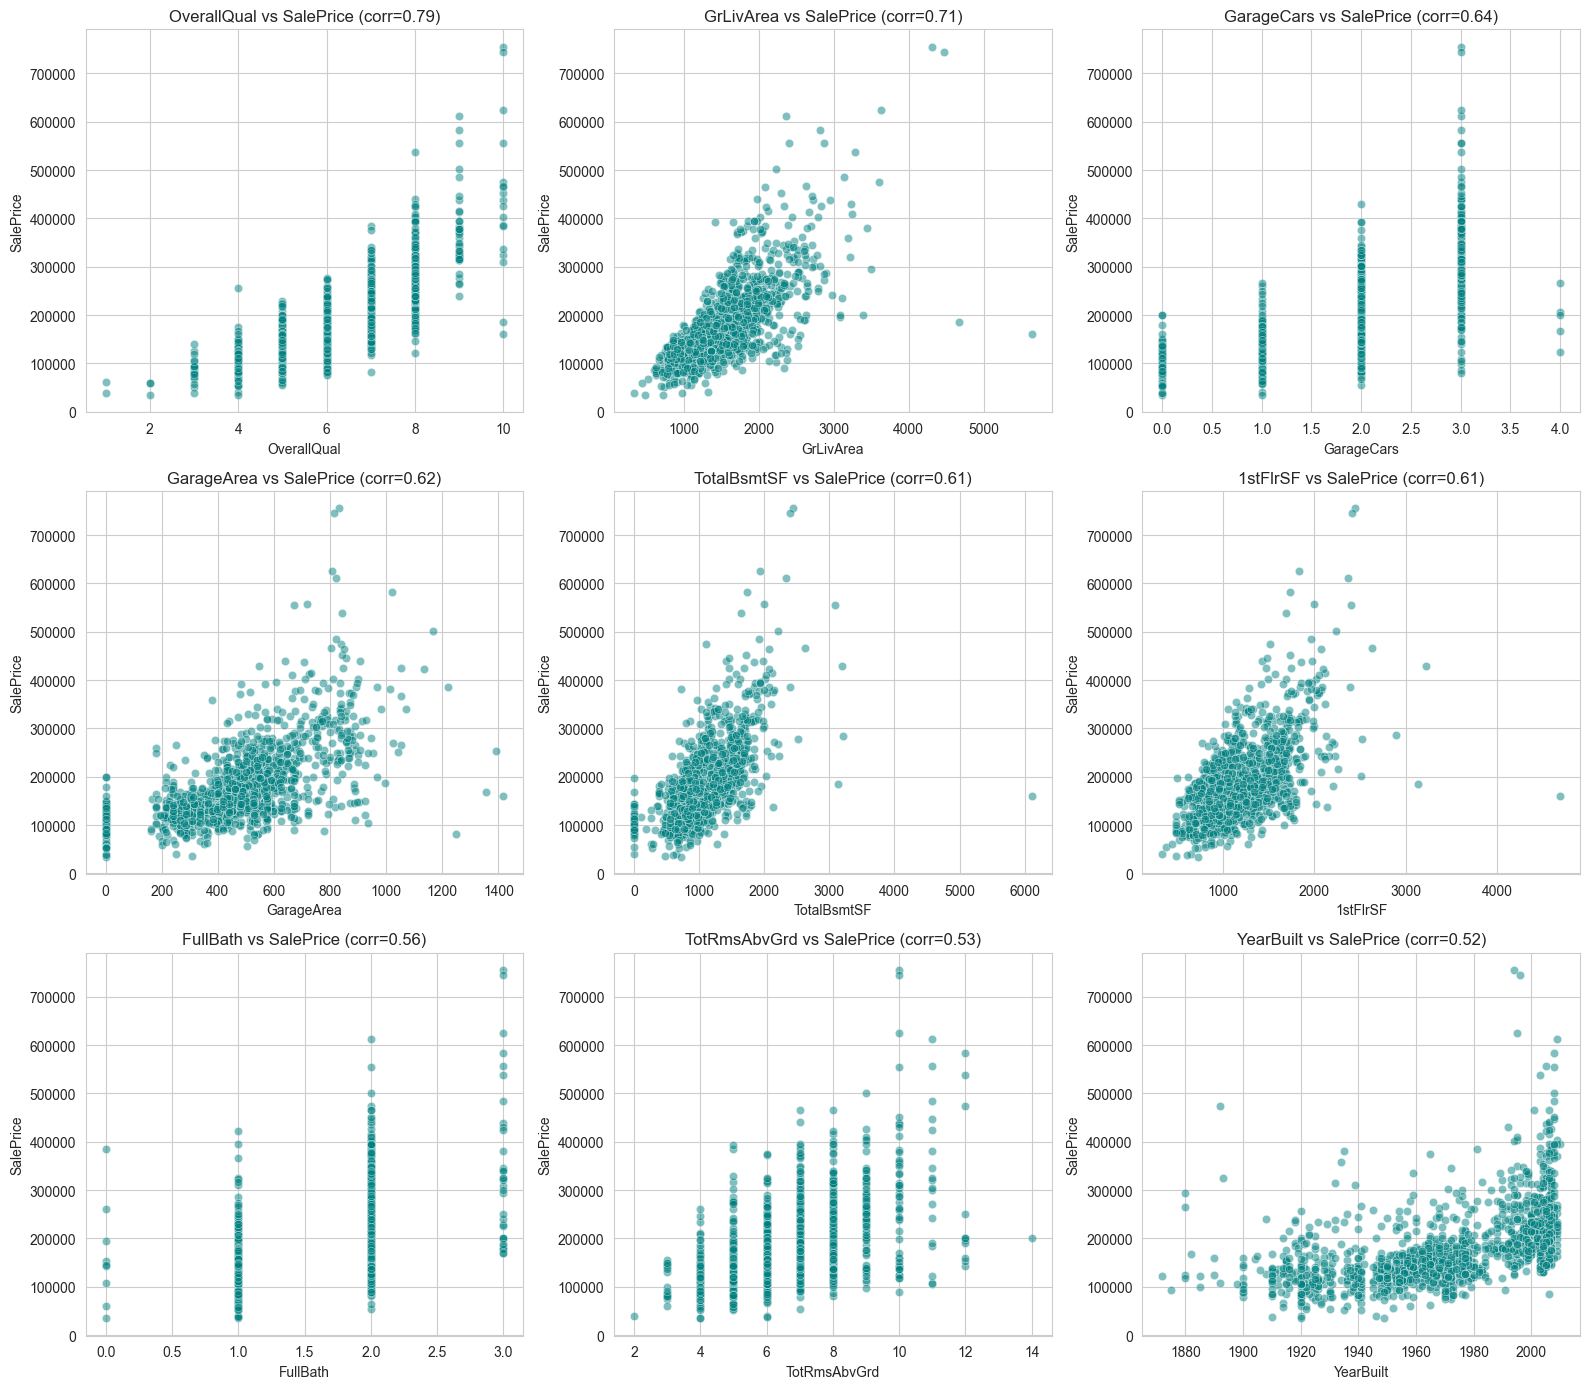

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()
 
for i, feat in enumerate(top_corr_feats):
    sns.scatterplot(x=train[feat], y=train["SalePrice"], ax=axes[i], alpha=0.5, color="teal")
    axes[i].set_title(f"{feat} vs SalePrice (corr={corr_with_target[feat]:.2f})")
 
plt.tight_layout()
plt.show()

In [10]:
outliers = train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)]
print(f"Outliers identified: {len(outliers)}")
outliers[["GrLivArea", "TotalBsmtSF", "SalePrice"]]

Outliers identified: 2


,GrLivArea,TotalBsmtSF,SalePrice
523,4676,3138,184750
1298,5642,6110,160000


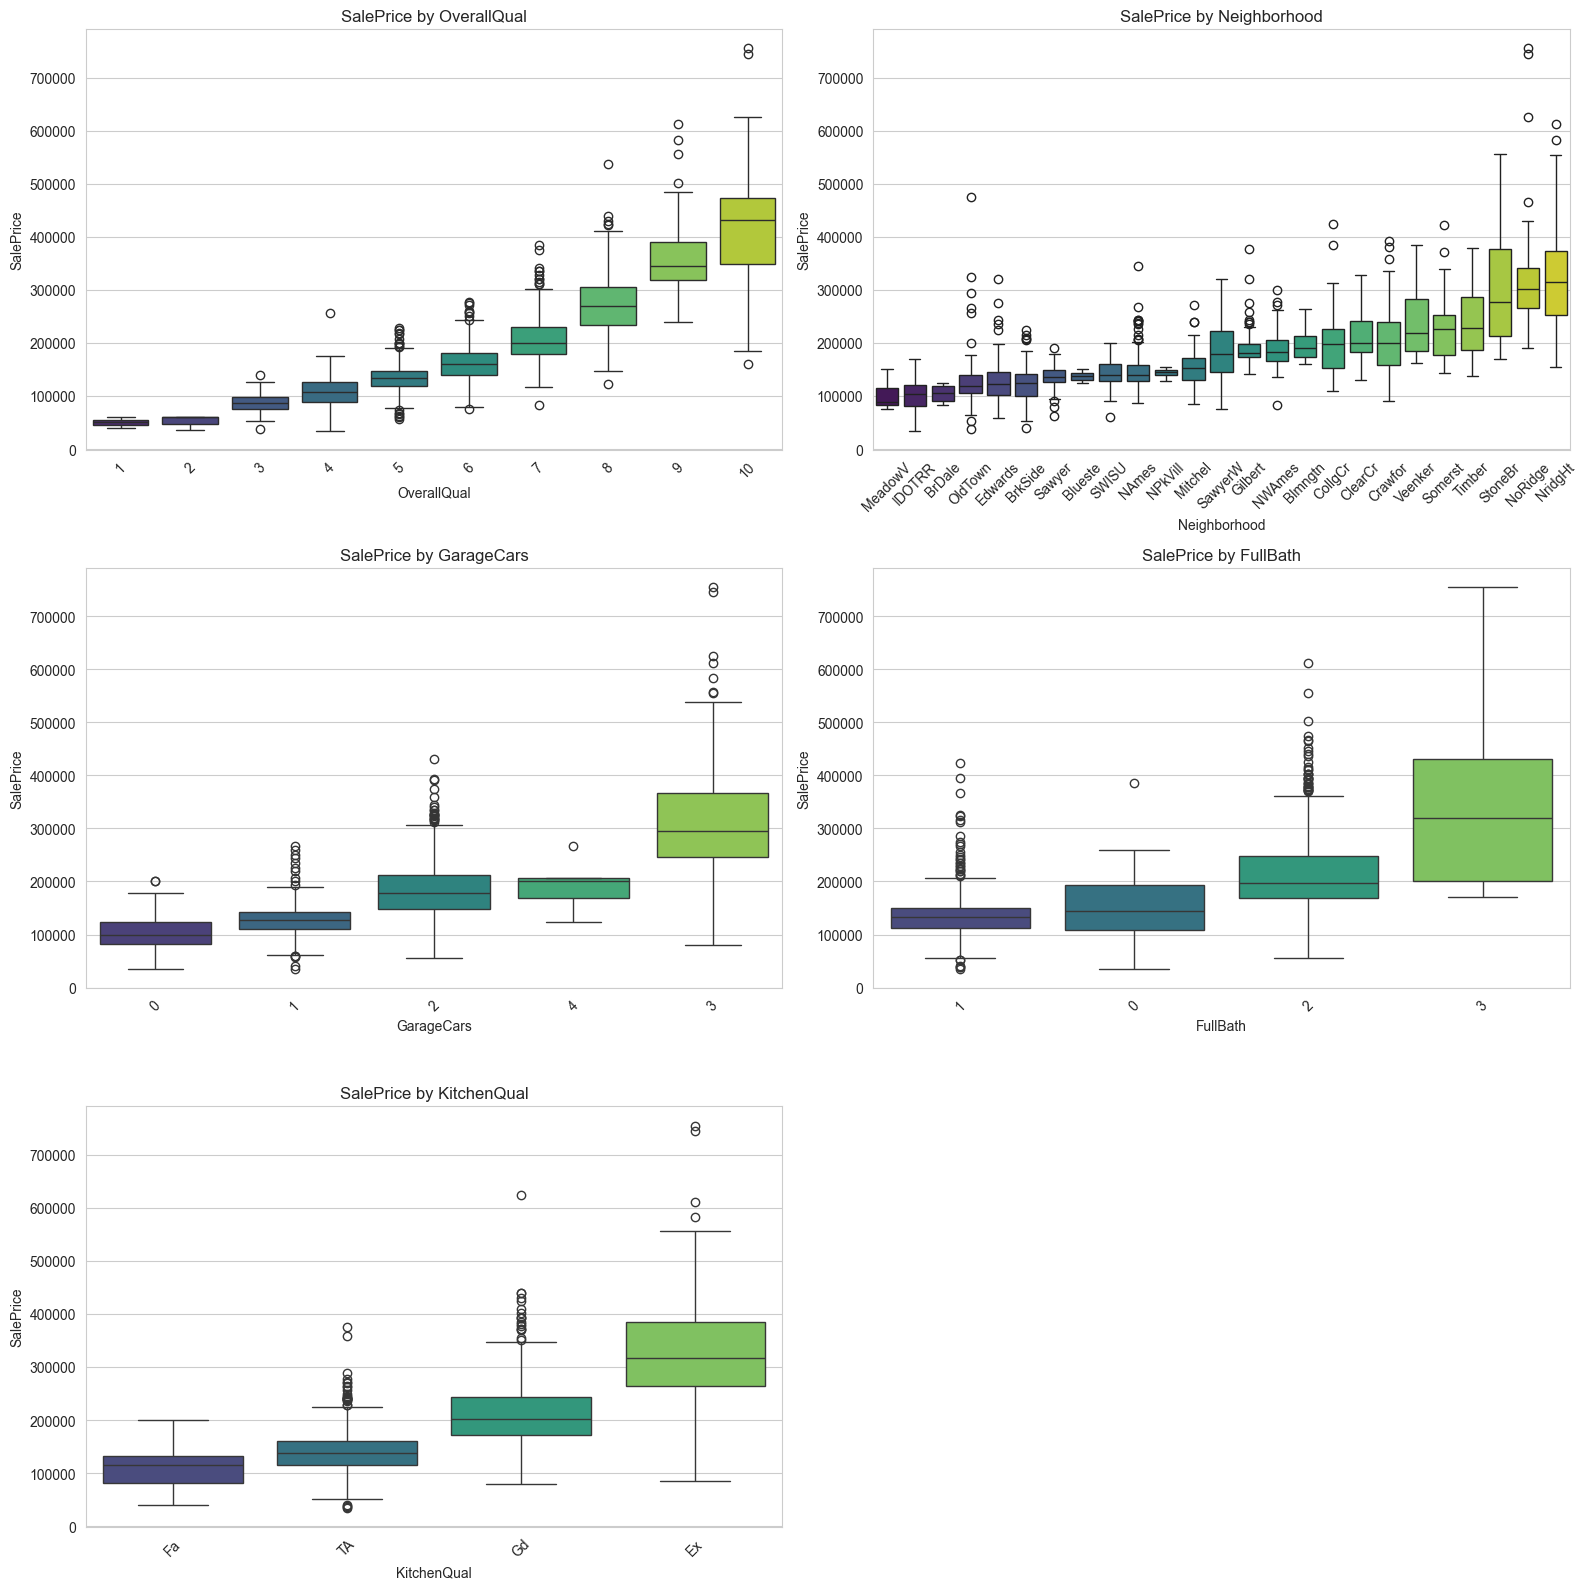

In [11]:
cat_feats_of_interest = ["OverallQual", "Neighborhood", "GarageCars", "FullBath", "KitchenQual"]
 
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
axes = axes.flatten()
 
for i, feat in enumerate(cat_feats_of_interest):
    order = train.groupby(feat)["SalePrice"].median().sort_values().index
    sns.boxplot(x=feat, y="SalePrice", data=train, order=order, ax=axes[i], palette="viridis")
    axes[i].set_title(f"SalePrice by {feat}")
    axes[i].tick_params(axis="x", rotation=45)
 
axes[-1].axis("off")
plt.tight_layout()
plt.show()

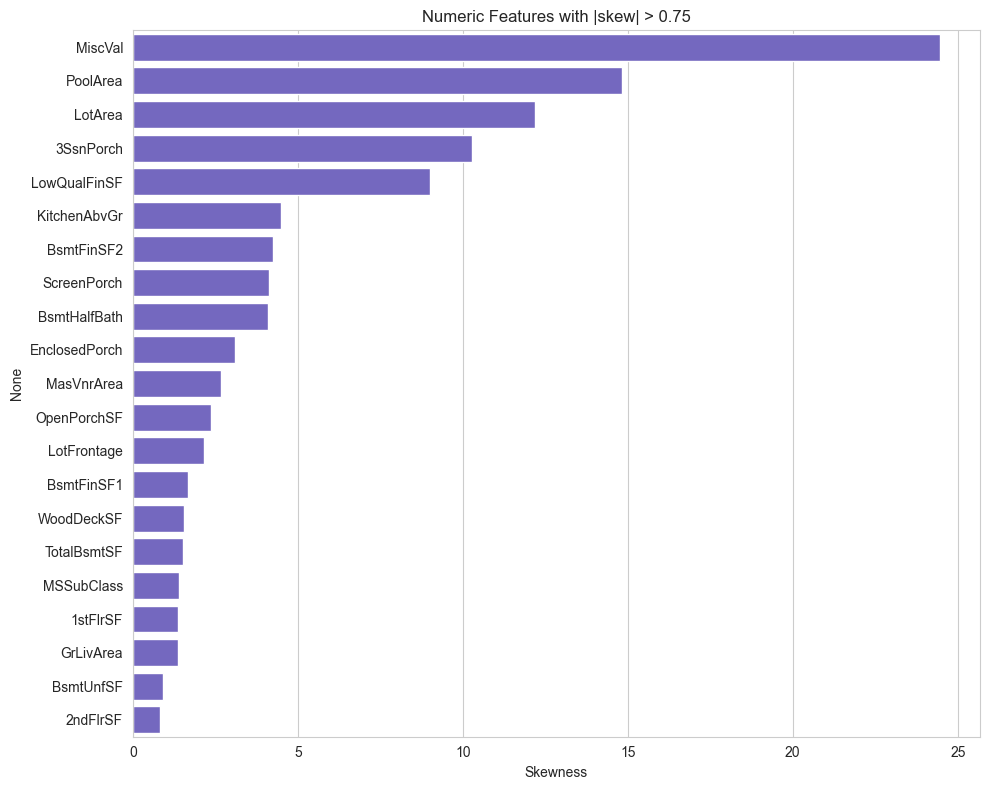

In [12]:
skewed = train[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
skewed_top = skewed[abs(skewed) > 0.75]
 
plt.figure(figsize=(10, 8))
sns.barplot(x=skewed_top.values, y=skewed_top.index, color="slateblue")
plt.title("Numeric Features with |skew| > 0.75")
plt.xlabel("Skewness")
plt.tight_layout()
plt.show()

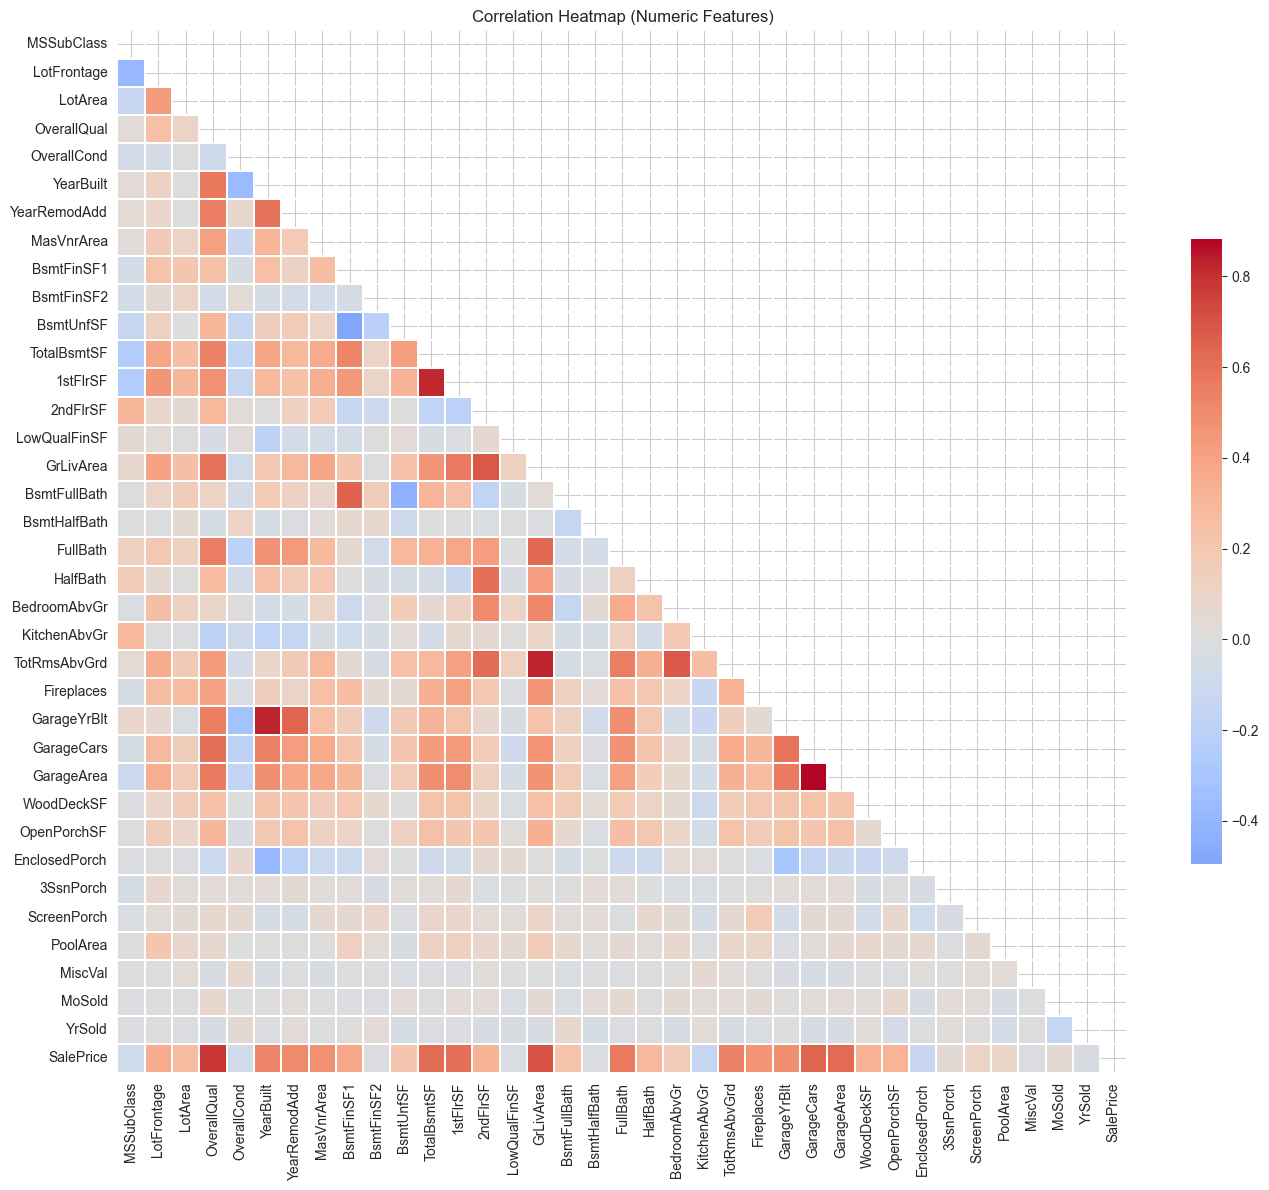

In [13]:
plt.figure(figsize=(14, 12))
corr_matrix = train[numeric_feats + ["SalePrice"]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0, linewidths=0.3,
            cbar_kws={"shrink": 0.6})
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

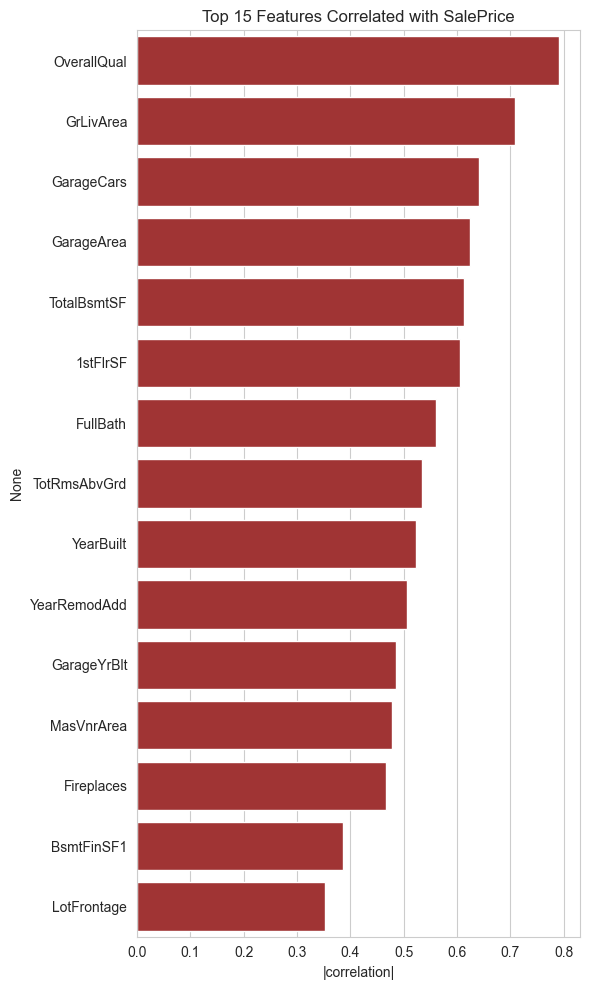

In [14]:
plt.figure(figsize=(6, 10))
top15 = corr_with_target.abs().sort_values(ascending=False).head(15)
sns.barplot(x=top15.values, y=top15.index, color="firebrick")
plt.title("Top 15 Features Correlated with SalePrice")
plt.xlabel("|correlation|")
plt.tight_layout()
plt.show()

## Additional Exploratory Analysis

A closer look at price levels by location, feature redundancy, and price trends over time before moving on to preprocessing.

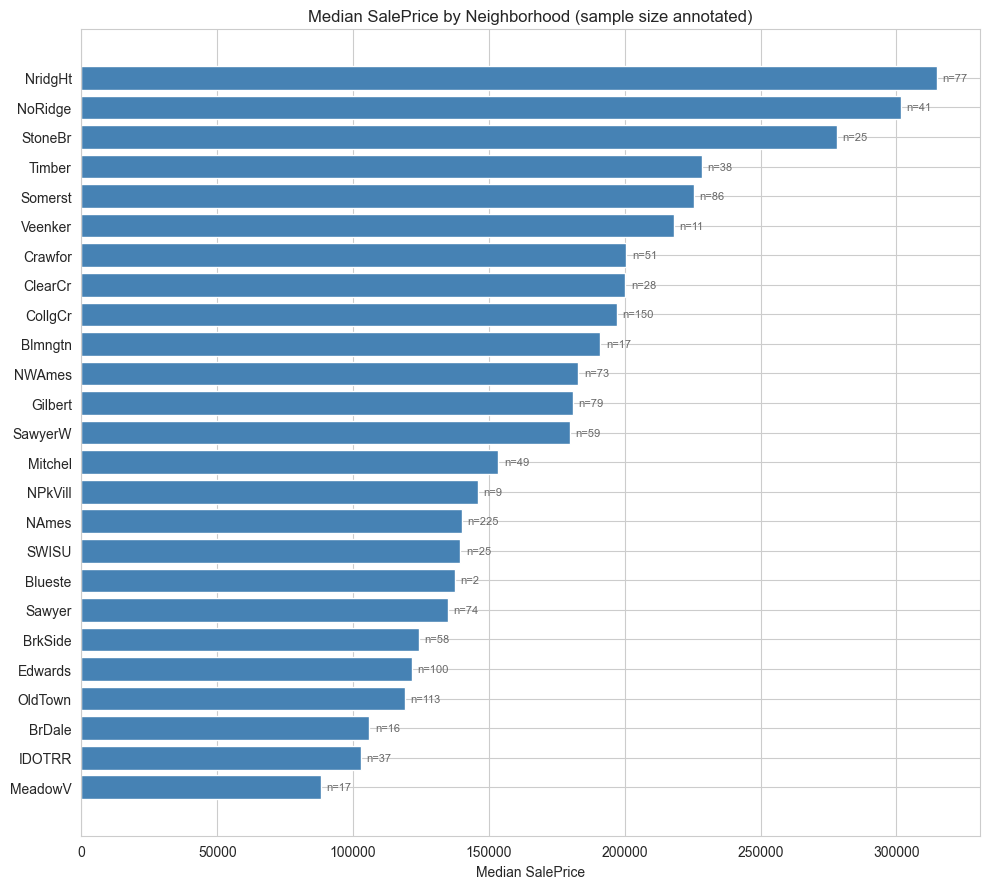

In [15]:
nbhd_stats = train.groupby("Neighborhood")["SalePrice"].agg(["median", "count"]).sort_values("median")

fig, ax = plt.subplots(figsize=(10, 9))
bars = ax.barh(nbhd_stats.index, nbhd_stats["median"], color="steelblue")
for bar, cnt in zip(bars, nbhd_stats["count"]):
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height() / 2,
            f"n={cnt}", va="center", fontsize=8, color="dimgray")
ax.set_xlabel("Median SalePrice")
ax.set_title("Median SalePrice by Neighborhood (sample size annotated)")
plt.tight_layout()
plt.show()

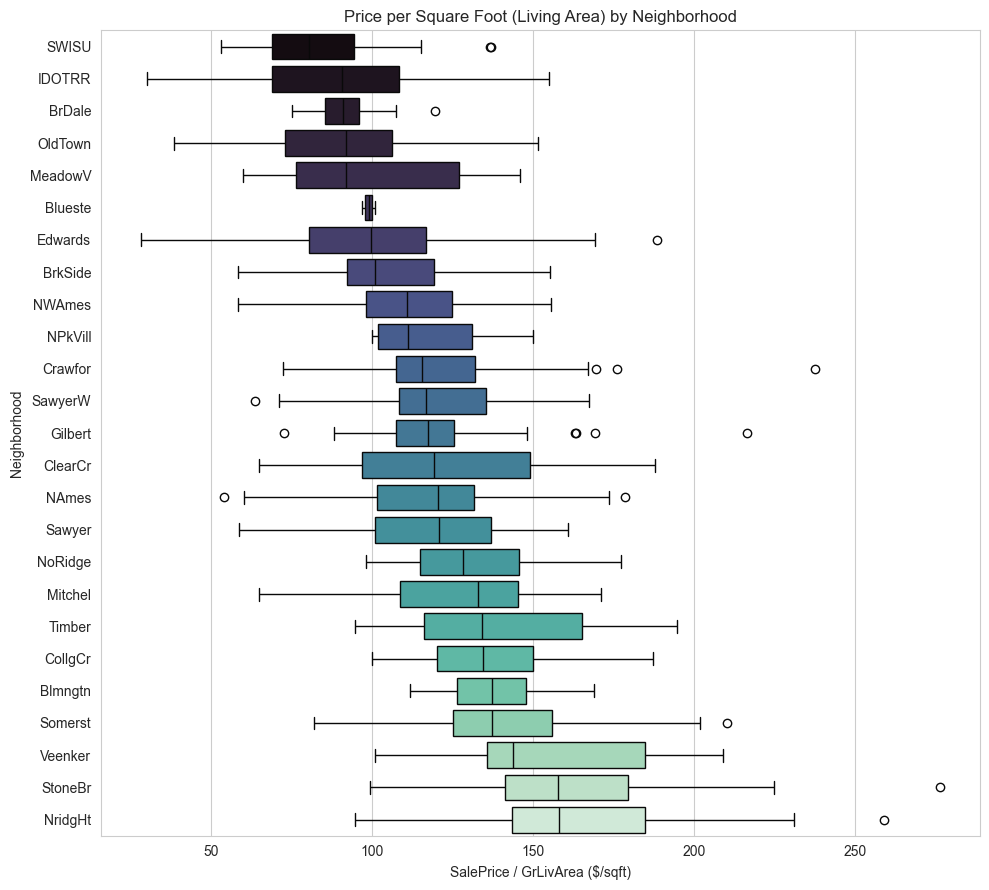

In [16]:
train["PricePerSF"] = train["SalePrice"] / train["GrLivArea"]
order = train.groupby("Neighborhood")["PricePerSF"].median().sort_values().index

plt.figure(figsize=(10, 9))
sns.boxplot(x="PricePerSF", y="Neighborhood", data=train, order=order, palette="mako")
plt.title("Price per Square Foot (Living Area) by Neighborhood")
plt.xlabel("SalePrice / GrLivArea ($/sqft)")
plt.tight_layout()
plt.show()

train.drop(columns=["PricePerSF"], inplace=True)

In [17]:
corr_abs = train[numeric_feats].corr().abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "Feature 1", "level_1": "Feature 2", 0: "AbsCorr"})
    .sort_values("AbsCorr", ascending=False)
)
high_corr_pairs = high_corr_pairs[high_corr_pairs["AbsCorr"] > 0.7]
print(f"{len(high_corr_pairs)} numeric feature pairs with |corr| > 0.7 (redundant signal, worth watching for the linear models)")
high_corr_pairs

4 numeric feature pairs with |corr| > 0.7 (redundant signal, worth watching for the linear models)


,Feature 1,Feature 2,AbsCorr
926,GarageCars,GarageArea,0.882475
204,YearBuilt,GarageYrBlt,0.825667
562,GrLivArea,TotRmsAbvGrd,0.825489
408,TotalBsmtSF,1stFlrSF,0.819530


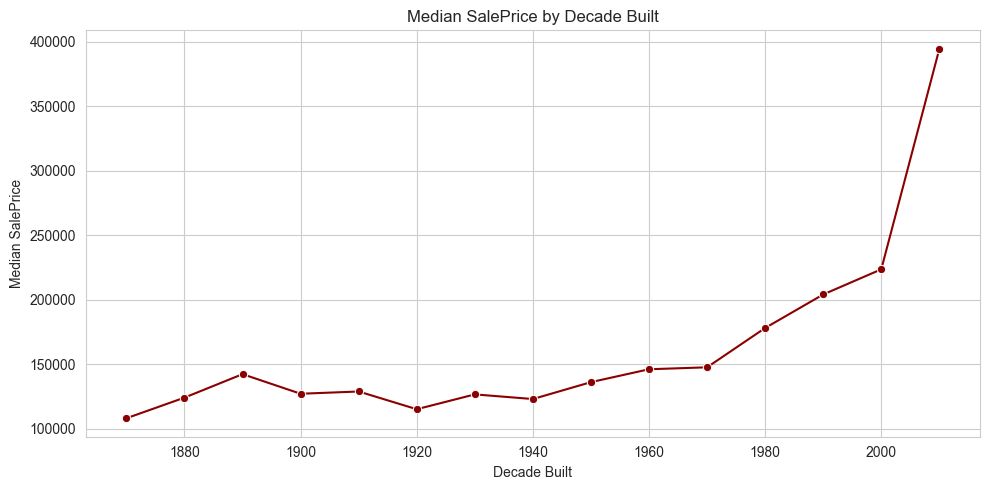

In [18]:
train["DecadeBuilt"] = (train["YearBuilt"] // 10 * 10).astype(int)
decade_price = train.groupby("DecadeBuilt")["SalePrice"].median()

plt.figure(figsize=(10, 5))
sns.lineplot(x=decade_price.index, y=decade_price.values, marker="o", color="darkred")
plt.title("Median SalePrice by Decade Built")
plt.xlabel("Decade Built")
plt.ylabel("Median SalePrice")
plt.tight_layout()
plt.show()

train.drop(columns=["DecadeBuilt"], inplace=True)

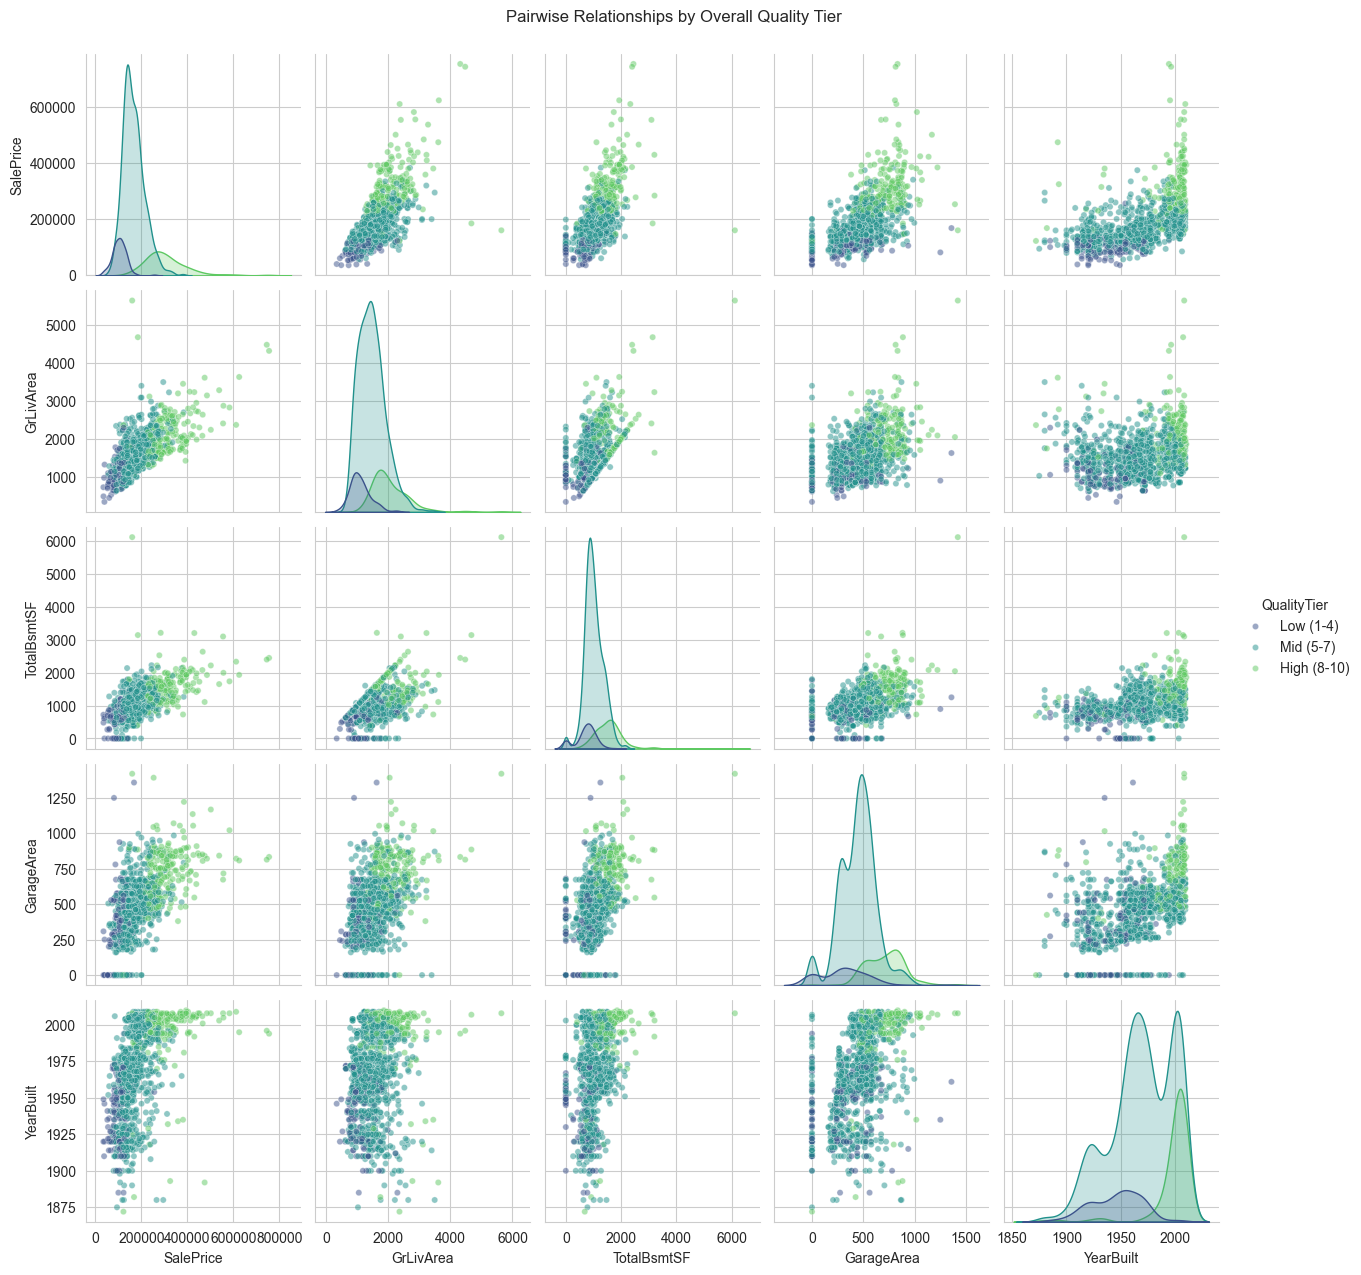

In [19]:
qual_tier = pd.cut(train["OverallQual"], bins=[0, 4, 7, 10], labels=["Low (1-4)", "Mid (5-7)", "High (8-10)"])
pairplot_feats = ["SalePrice", "GrLivArea", "TotalBsmtSF", "GarageArea", "YearBuilt"]

pp_df = train[pairplot_feats].copy()
pp_df["QualityTier"] = qual_tier

g = sns.pairplot(pp_df, hue="QualityTier", palette="viridis", diag_kind="kde",
                  plot_kws={"alpha": 0.5, "s": 20})
g.fig.suptitle("Pairwise Relationships by Overall Quality Tier", y=1.02)
plt.show()

In [20]:
train = train.drop(outliers.index)
 
y_train = train["SalePriceLog"].reset_index(drop=True)
train_features = train.drop(["SalePrice", "SalePriceLog"], axis=1)
 
n_train = train_features.shape[0]
all_data = pd.concat([train_features, test], axis=0).reset_index(drop=True)
print("Combined shape:", all_data.shape)

Combined shape: (2917, 79)


In [21]:
none_cols = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu",
             "GarageType", "GarageFinish", "GarageQual", "GarageCond",
             "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
             "MasVnrType"]
for col in none_cols:
    all_data[col] = all_data[col].fillna("None")
 
# Numeric features where NaN means "0" (e.g. no garage -> 0 garage area)
zero_cols = ["GarageYrBlt", "GarageArea", "GarageCars",
             "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
             "BsmtFullBath", "BsmtHalfBath", "MasVnrArea"]
for col in zero_cols:
    all_data[col] = all_data[col].fillna(0)
 
# LotFrontage: impute using the median within each Neighborhood
all_data["LotFrontage"] = all_data.groupby("Neighborhood")["LotFrontage"] \
    .transform(lambda x: x.fillna(x.median()))
 
# A handful of columns with only a few missing values: fill with the mode
mode_cols = ["MSZoning", "Electrical", "KitchenQual", "Exterior1st",
             "Exterior2nd", "SaleType", "Functional"]
for col in mode_cols:
    all_data[col] = all_data[col].fillna(all_data[col].mode()[0])
 
# Utilities is almost constant and not useful -- drop it
all_data.drop("Utilities", axis=1, inplace=True)
 
print("Remaining missing values:", all_data.isnull().sum().sum())

Remaining missing values: 0


In [22]:
all_data["TotalSF"] = all_data["TotalBsmtSF"] + all_data["1stFlrSF"] + all_data["2ndFlrSF"]
all_data["TotalBathrooms"] = (all_data["FullBath"] + 0.5 * all_data["HalfBath"] +
                              all_data["BsmtFullBath"] + 0.5 * all_data["BsmtHalfBath"])
all_data["TotalPorchSF"] = (all_data["OpenPorchSF"] + all_data["3SsnPorch"] +
                            all_data["EnclosedPorch"] + all_data["ScreenPorch"] +
                            all_data["WoodDeckSF"])
all_data["HouseAge"] = all_data["YrSold"] - all_data["YearBuilt"]
all_data["RemodAge"] = all_data["YrSold"] - all_data["YearRemodAdd"]
all_data["IsRemodeled"] = (all_data["YearBuilt"] != all_data["YearRemodAdd"]).astype(int)
all_data["HasPool"] = (all_data["PoolArea"] > 0).astype(int)
all_data["Has2ndFloor"] = (all_data["2ndFlrSF"] > 0).astype(int)
all_data["HasGarage"] = (all_data["GarageArea"] > 0).astype(int)
all_data["HasBsmt"] = (all_data["TotalBsmtSF"] > 0).astype(int)
all_data["HasFireplace"] = (all_data["Fireplaces"] > 0).astype(int)
 
# Some numeric-looking columns are really categories
for col in ["MSSubClass", "OverallCond", "YrSold", "MoSold"]:
    all_data[col] = all_data[col].astype(str)
 
print("Shape after feature engineering:", all_data.shape)

Shape after feature engineering: (2917, 89)


In [23]:
numeric_cols = all_data.select_dtypes(include=[np.number]).columns
skewed_feats = all_data[numeric_cols].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
high_skew = skewed_feats[abs(skewed_feats) > 0.75]
print(f"{len(high_skew)} numeric features are highly skewed, applying boxcox1p")
 
from scipy.special import boxcox1p
lam = 0.15
for feat in high_skew.index:
    all_data[feat] = boxcox1p(all_data[feat], lam)

25 numeric features are highly skewed, applying boxcox1p


In [24]:
all_data_encoded = pd.get_dummies(all_data)
print("Shape after one-hot encoding:", all_data_encoded.shape)
 
X_train_full = all_data_encoded.iloc[:n_train, :].reset_index(drop=True)
X_test_full = all_data_encoded.iloc[n_train:, :].reset_index(drop=True)
 
X_train_full.shape, X_test_full.shape, y_train.shape

Shape after one-hot encoding: (2917, 348)


((1458, 348), (1459, 348), (1458,))

In [25]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train, test_size=0.2, random_state=RANDOM_STATE
)
 
scaler = RobustScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_val_scaled = scaler.transform(X_val)
X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_full_scaled = scaler.transform(X_test_full)

In [26]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
 
def cv_rmse(model, X, y):
    scores = -cross_val_score(model, X, y, scoring="neg_root_mean_squared_error", cv=kf)
    return scores
 
models = {
    "Ridge": Ridge(alpha=10.0, random_state=RANDOM_STATE),
    "Lasso": Lasso(alpha=0.0005, random_state=RANDOM_STATE, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=0.0005, l1_ratio=0.9, random_state=RANDOM_STATE, max_iter=10000),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                   max_depth=3, random_state=RANDOM_STATE),
}
 
if HAS_XGB:
    models["XGBoost"] = XGBRegressor(
        n_estimators=1000, learning_rate=0.03, max_depth=3,
        subsample=0.8, colsample_bytree=0.6, random_state=RANDOM_STATE, n_jobs=-1
    )
 
if HAS_LGBM:
    models["LightGBM"] = LGBMRegressor(
        n_estimators=1000, learning_rate=0.03, num_leaves=6,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )
 
results = {}
for name, model in models.items():
    X_in = X_train_full_scaled if name in ("Ridge", "Lasso", "ElasticNet") else X_train_full
    scores = cv_rmse(model, X_in, y_train)
    results[name] = scores
    print(f"{name:>18s}: RMSE = {scores.mean():.4f}  (+/- {scores.std():.4f})")
 

             Ridge: RMSE = 0.1129  (+/- 0.0086)
             Lasso: RMSE = 0.1108  (+/- 0.0076)
        ElasticNet: RMSE = 0.1108  (+/- 0.0077)
      RandomForest: RMSE = 0.1377  (+/- 0.0067)
  GradientBoosting: RMSE = 0.1242  (+/- 0.0056)
           XGBoost: RMSE = 0.1150  (+/- 0.0062)
          LightGBM: RMSE = 0.1241  (+/- 0.0074)


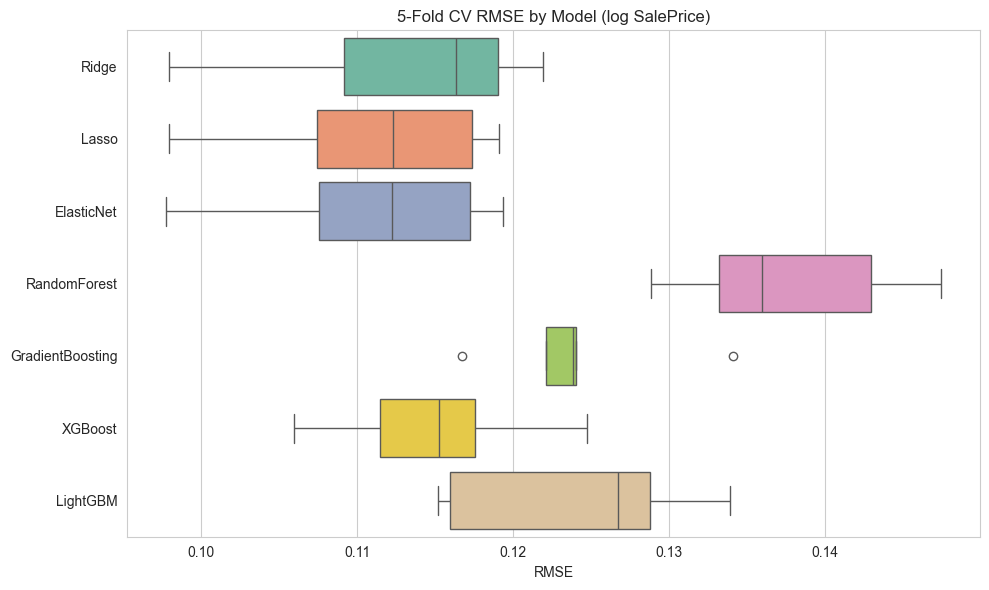

In [27]:
results_df = pd.DataFrame(results)
 
plt.figure(figsize=(10, 6))
sns.boxplot(data=results_df, orient="h", palette="Set2")
plt.title("5-Fold CV RMSE by Model (log SalePrice)")
plt.xlabel("RMSE")
plt.tight_layout()
plt.show()

In [28]:
final_ridge = Ridge(alpha=10.0, random_state=RANDOM_STATE)
final_lasso = Lasso(alpha=0.0005, random_state=RANDOM_STATE, max_iter=10000)
final_enet = ElasticNet(alpha=0.0005, l1_ratio=0.9, random_state=RANDOM_STATE, max_iter=10000)
final_gbr = GradientBoostingRegressor(
    n_estimators=3000, learning_rate=0.02, max_depth=4, max_features="sqrt",
    min_samples_leaf=15, min_samples_split=10, loss="huber", random_state=RANDOM_STATE
)
 
estimators = [
    ("ridge", final_ridge),
    ("lasso", final_lasso),
    ("enet", final_enet),
    ("gbr", final_gbr),
]
 
if HAS_XGB:
    estimators.append(("xgb", XGBRegressor(
        n_estimators=2000, learning_rate=0.02, max_depth=3,
        subsample=0.7, colsample_bytree=0.6, random_state=RANDOM_STATE, n_jobs=-1
    )))
if HAS_LGBM:
    estimators.append(("lgbm", LGBMRegressor(
        n_estimators=2000, learning_rate=0.02, num_leaves=5,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )))
 
estimators

[('ridge', Ridge(alpha=10.0, random_state=42)),
 ('lasso', Lasso(alpha=0.0005, max_iter=10000, random_state=42)),
 ('enet',
  ElasticNet(alpha=0.0005, l1_ratio=0.9, max_iter=10000, random_state=42)),
 ('gbr',
  GradientBoostingRegressor(learning_rate=0.02, loss='huber', max_depth=4,
                            max_features='sqrt', min_samples_leaf=15,
                            min_samples_split=10, n_estimators=3000,
                            random_state=42)),
 ('xgb',
  XGBRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.6, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.02, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=

In [29]:
val_preds = {}
val_rmses = {}
for name, model in estimators:
    X_in_tr = X_tr_scaled if name in ("ridge", "lasso", "enet") else X_tr
    X_in_val = X_val_scaled if name in ("ridge", "lasso", "enet") else X_val
    model.fit(X_in_tr, y_tr)
    preds = model.predict(X_in_val)
    val_preds[name] = preds
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    val_rmses[name] = rmse
    print(f"{name:>8s} validation RMSE: {rmse:.4f}")

best_name = min(val_rmses, key=val_rmses.get)
print(f"\nBest single model on the hold-out split: {best_name} (RMSE={val_rmses[best_name]:.4f})")

   ridge validation RMSE: 0.1190
   lasso validation RMSE: 0.1123
    enet validation RMSE: 0.1122
     gbr validation RMSE: 0.1242
     xgb validation RMSE: 0.1152
    lgbm validation RMSE: 0.1293

Best single model on the hold-out split: enet (RMSE=0.1122)


## Model Diagnostics (Hold-out Validation)

The diagnostics below use models fit only on the 80% training split (`X_tr`/`y_tr`) and evaluated on the untouched 20% hold-out (`X_val`/`y_val`), so there is no leakage into these plots. The best single model on this split is used for the residual and error analysis; permutation importance and the learning curve give complementary views of what drives the predictions and whether more data would help.

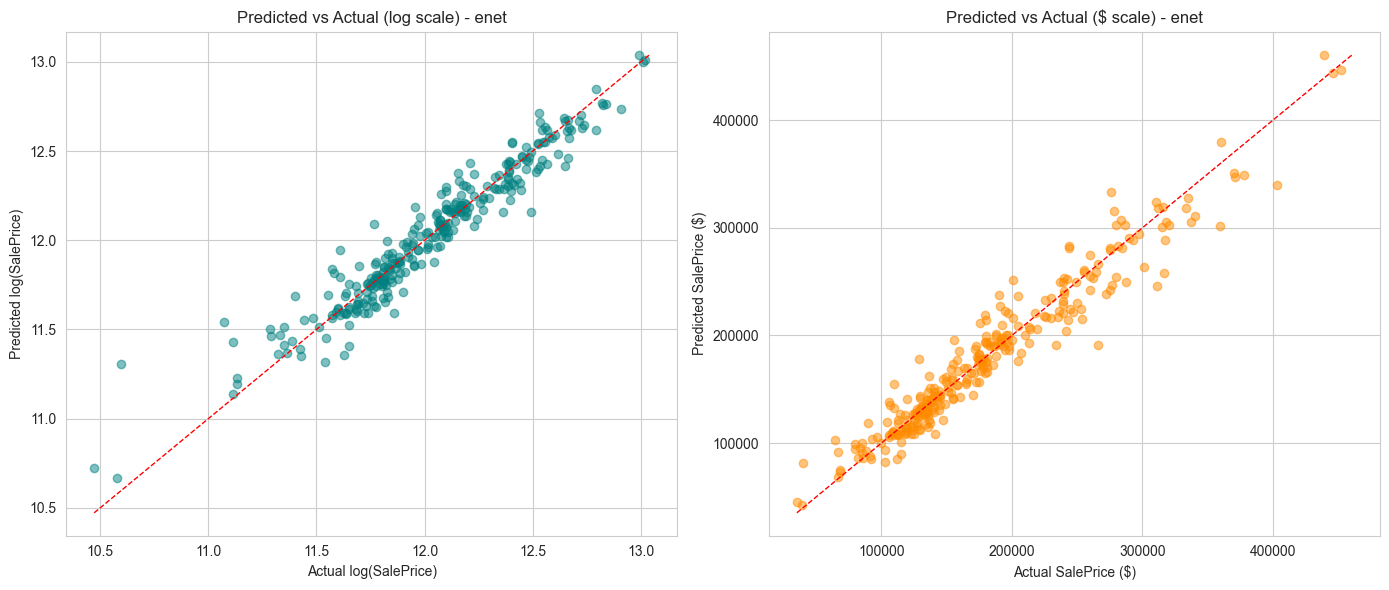

Hold-out R^2 (log scale): 0.9253


In [30]:
best_val_preds_log = val_preds[best_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_val, best_val_preds_log, alpha=0.5, color="teal")
lims = [min(y_val.min(), best_val_preds_log.min()), max(y_val.max(), best_val_preds_log.max())]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("Actual log(SalePrice)")
axes[0].set_ylabel("Predicted log(SalePrice)")
axes[0].set_title(f"Predicted vs Actual (log scale) - {best_name}")

actual_dollar = np.expm1(y_val)
pred_dollar = np.expm1(best_val_preds_log)
axes[1].scatter(actual_dollar, pred_dollar, alpha=0.5, color="darkorange")
lims2 = [min(actual_dollar.min(), pred_dollar.min()), max(actual_dollar.max(), pred_dollar.max())]
axes[1].plot(lims2, lims2, "r--", linewidth=1)
axes[1].set_xlabel("Actual SalePrice ($)")
axes[1].set_ylabel("Predicted SalePrice ($)")
axes[1].set_title(f"Predicted vs Actual ($ scale) - {best_name}")

plt.tight_layout()
plt.show()

r2 = 1 - np.sum((y_val - best_val_preds_log) ** 2) / np.sum((y_val - y_val.mean()) ** 2)
print(f"Hold-out R^2 (log scale): {r2:.4f}")

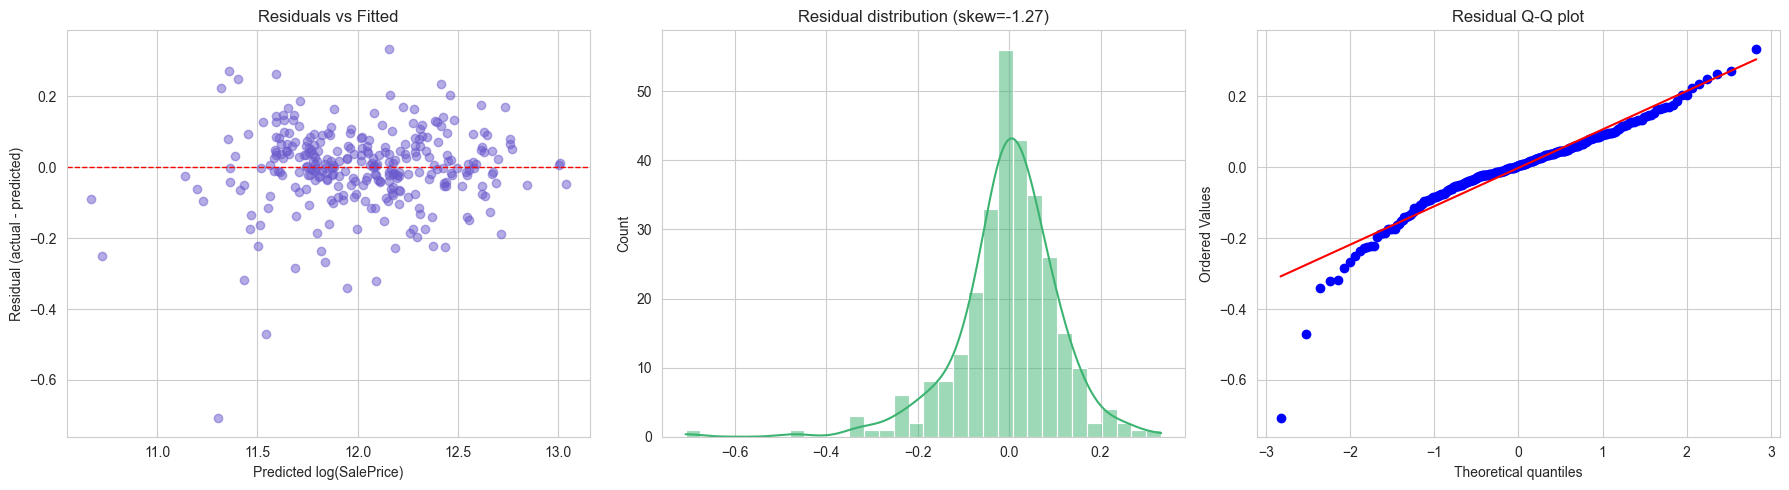

In [31]:
best_val_preds_log = val_preds[best_name]
residuals = y_val.reset_index(drop=True) - pd.Series(best_val_preds_log)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(best_val_preds_log, residuals, alpha=0.5, color="slateblue")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Predicted log(SalePrice)")
axes[0].set_ylabel("Residual (actual - predicted)")
axes[0].set_title("Residuals vs Fitted")

sns.histplot(residuals, kde=True, ax=axes[1], color="mediumseagreen")
axes[1].set_title(f"Residual distribution (skew={skew(residuals):.2f})")

stats.probplot(residuals, plot=axes[2])
axes[2].set_title("Residual Q-Q plot")

plt.tight_layout()
plt.show()

In [32]:
train_raw = train.reset_index(drop=True)
context_cols = ["Neighborhood", "OverallQual", "GrLivArea", "YearBuilt"]

error_table = pd.DataFrame({
    "ActualPrice": np.expm1(y_val.values),
    "PredictedPrice": np.expm1(val_preds[best_name]),
}, index=X_val.index)
error_table["AbsError"] = (error_table["ActualPrice"] - error_table["PredictedPrice"]).abs()
error_table["PctError"] = 100 * error_table["AbsError"] / error_table["ActualPrice"]
error_table = error_table.join(train_raw.loc[X_val.index, context_cols])

worst = error_table.sort_values("AbsError", ascending=False).head(15)
worst[context_cols + ["ActualPrice", "PredictedPrice", "AbsError", "PctError"]]

,Neighborhood,OverallQual,GrLivArea,YearBuilt,ActualPrice,PredictedPrice,AbsError,PctError
746,OldTown,7,2640,1880,265979.0,190689.838324,75289.161676,28.306431
218,Crawfor,7,1954,1939,311500.0,246289.301088,65210.698912,20.934414
231,NoRidge,8,2794,1995,403000.0,340137.176271,62862.823729,15.598716
567,SawyerW,8,2132,1983,316600.0,258343.758225,58256.241775,18.400582
607,Crawfor,8,3194,1934,359100.0,301762.713242,57337.286758,15.966941
261,CollgCr,8,2574,2007,276000.0,333225.504555,57225.504555,20.733878
528,Crawfor,6,2515,1957,200624.0,251493.056073,50869.056073,25.355419
665,NAmes,6,2380,1965,129000.0,178048.087184,49048.087184,38.021773
1320,NoRidge,7,1923,1992,190000.0,237500.783952,47500.783952,25.000413
727,NAmes,5,1776,1958,110000.0,154562.520909,44562.520909,40.511383


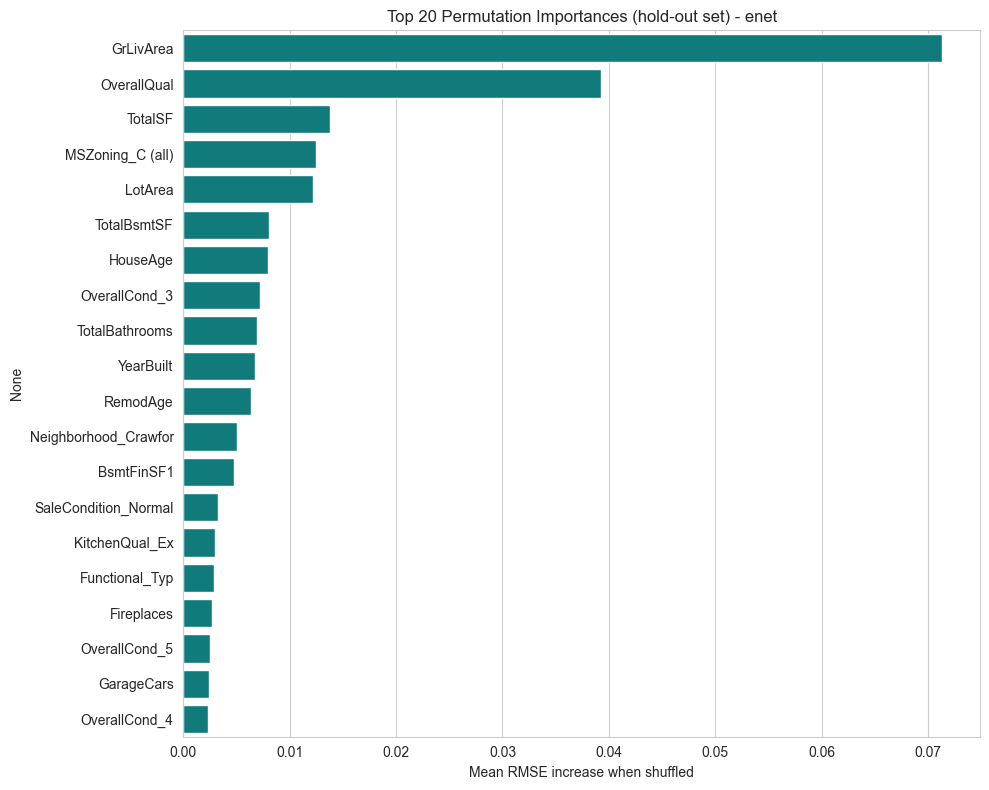

In [33]:
from sklearn.inspection import permutation_importance

best_model = dict(estimators)[best_name]
X_perm = X_val_scaled if best_name in ("ridge", "lasso", "enet") else X_val
feature_names = X_val.columns

perm_result = permutation_importance(
    best_model, X_perm, y_val, n_repeats=10, random_state=RANDOM_STATE,
    scoring="neg_root_mean_squared_error", n_jobs=-1
)
perm_importances = pd.Series(perm_result.importances_mean, index=feature_names).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(x=perm_importances.values, y=perm_importances.index, color="darkcyan")
plt.title(f"Top 20 Permutation Importances (hold-out set) - {best_name}")
plt.xlabel("Mean RMSE increase when shuffled")
plt.tight_layout()
plt.show()

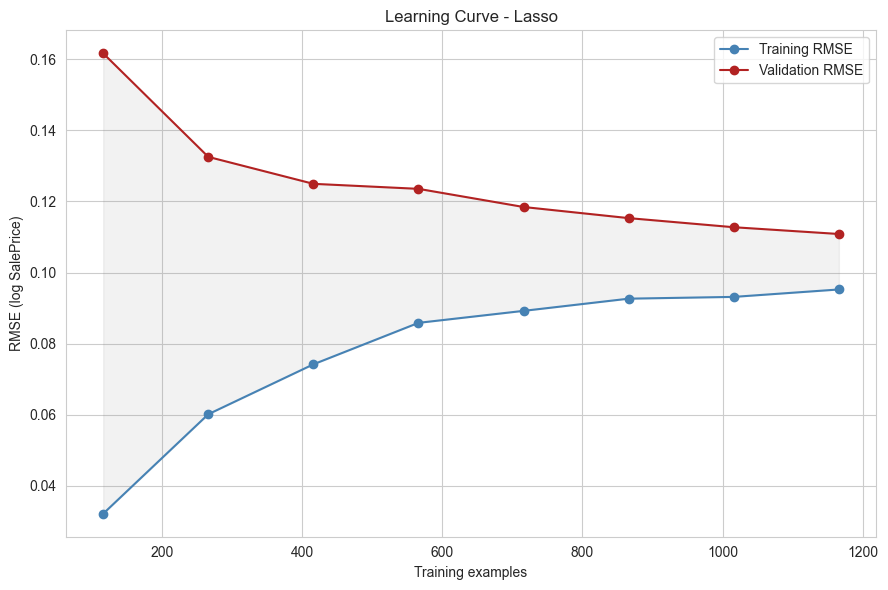

In [34]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    Lasso(alpha=0.0005, random_state=RANDOM_STATE, max_iter=10000),
    X_train_full_scaled, y_train,
    cv=kf, scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1
)

train_rmse = -train_scores.mean(axis=1)
val_rmse = -val_scores.mean(axis=1)

plt.figure(figsize=(9, 6))
plt.plot(train_sizes, train_rmse, "o-", color="steelblue", label="Training RMSE")
plt.plot(train_sizes, val_rmse, "o-", color="firebrick", label="Validation RMSE")
plt.fill_between(train_sizes, train_rmse, val_rmse, alpha=0.1, color="gray")
plt.xlabel("Training examples")
plt.ylabel("RMSE (log SalePrice)")
plt.title("Learning Curve - Lasso")
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
from sklearn.model_selection import cross_val_predict

stack_estimators = [(name, model) for name, model in estimators]

stacked_model = StackingRegressor(
    estimators=stack_estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=kf,
    n_jobs=-1,
)

# Out-of-fold predictions give an unbiased view of the stacked model's error for diagnostics,
# while reusing the same 5-fold split as the base-model comparison above.
oof_preds_log = cross_val_predict(stacked_model, X_train_full_scaled, y_train, cv=kf, n_jobs=-1)

stack_fold_rmses = np.array([
    np.sqrt(mean_squared_error(y_train.iloc[val_idx], oof_preds_log[val_idx]))
    for _, val_idx in kf.split(X_train_full_scaled)
])
print(f"Stacked ensemble CV RMSE: {stack_fold_rmses.mean():.4f}  (+/- {stack_fold_rmses.std():.4f})")

results["Stacked"] = stack_fold_rmses
results_df = pd.DataFrame(results)

stacked_model.fit(X_train_full_scaled, y_train)

Stacked ensemble CV RMSE: 0.1081  (+/- 0.0082)


,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('ridge', ...), ('lasso', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",Ridge()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",KFold(n_split... shuffle=True)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",10.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no 

### Stacked Ensemble Diagnostics (Out-of-Fold)

These plots use out-of-fold predictions from the same 5-fold CV used for evaluation, so they are unbiased and directly represent the model behind the final submission.

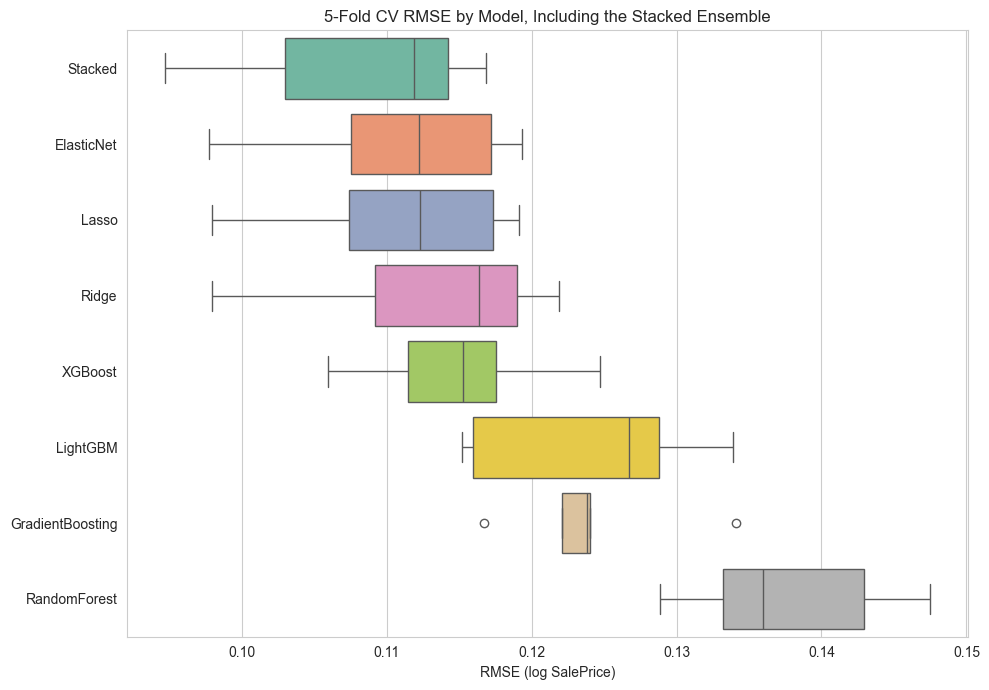

In [36]:
plt.figure(figsize=(10, 7))
order = results_df.mean().sort_values().index
sns.boxplot(data=results_df[order], orient="h", palette="Set2")
plt.title("5-Fold CV RMSE by Model, Including the Stacked Ensemble")
plt.xlabel("RMSE (log SalePrice)")
plt.tight_layout()
plt.show()

In [37]:
summary_tbl = pd.DataFrame({
    "MeanRMSE": results_df.mean(),
    "StdRMSE": results_df.std(),
}).sort_values("MeanRMSE")
summary_tbl

,MeanRMSE,StdRMSE
Stacked,0.108145,0.009133
ElasticNet,0.110818,0.008633
Lasso,0.110828,0.008527
Ridge,0.112878,0.009593
XGBoost,0.114993,0.006982
LightGBM,0.124122,0.008221
GradientBoosting,0.124166,0.006306
RandomForest,0.137682,0.007496


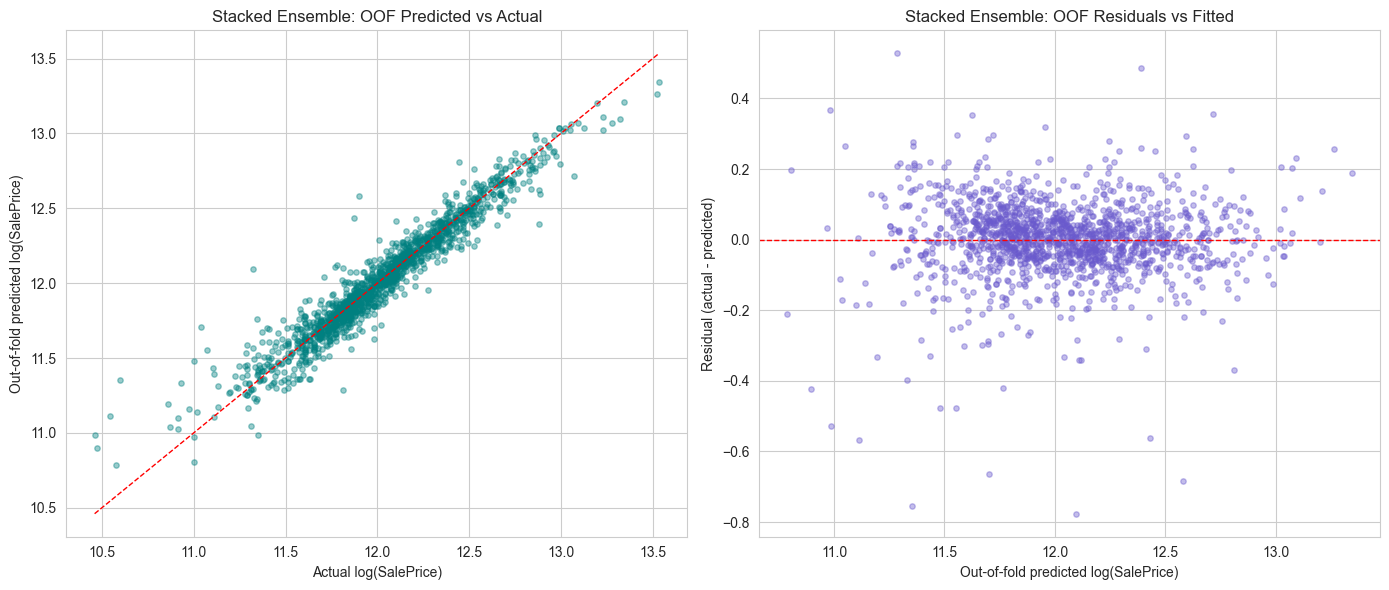

Out-of-fold R^2 (log scale): 0.9263


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_train, oof_preds_log, alpha=0.4, color="teal", s=15)
lims = [y_train.min(), y_train.max()]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("Actual log(SalePrice)")
axes[0].set_ylabel("Out-of-fold predicted log(SalePrice)")
axes[0].set_title("Stacked Ensemble: OOF Predicted vs Actual")

oof_residuals = y_train - oof_preds_log
axes[1].scatter(oof_preds_log, oof_residuals, alpha=0.4, color="slateblue", s=15)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Out-of-fold predicted log(SalePrice)")
axes[1].set_ylabel("Residual (actual - predicted)")
axes[1].set_title("Stacked Ensemble: OOF Residuals vs Fitted")

plt.tight_layout()
plt.show()

oof_r2 = 1 - np.sum(oof_residuals ** 2) / np.sum((y_train - y_train.mean()) ** 2)
print(f"Out-of-fold R^2 (log scale): {oof_r2:.4f}")

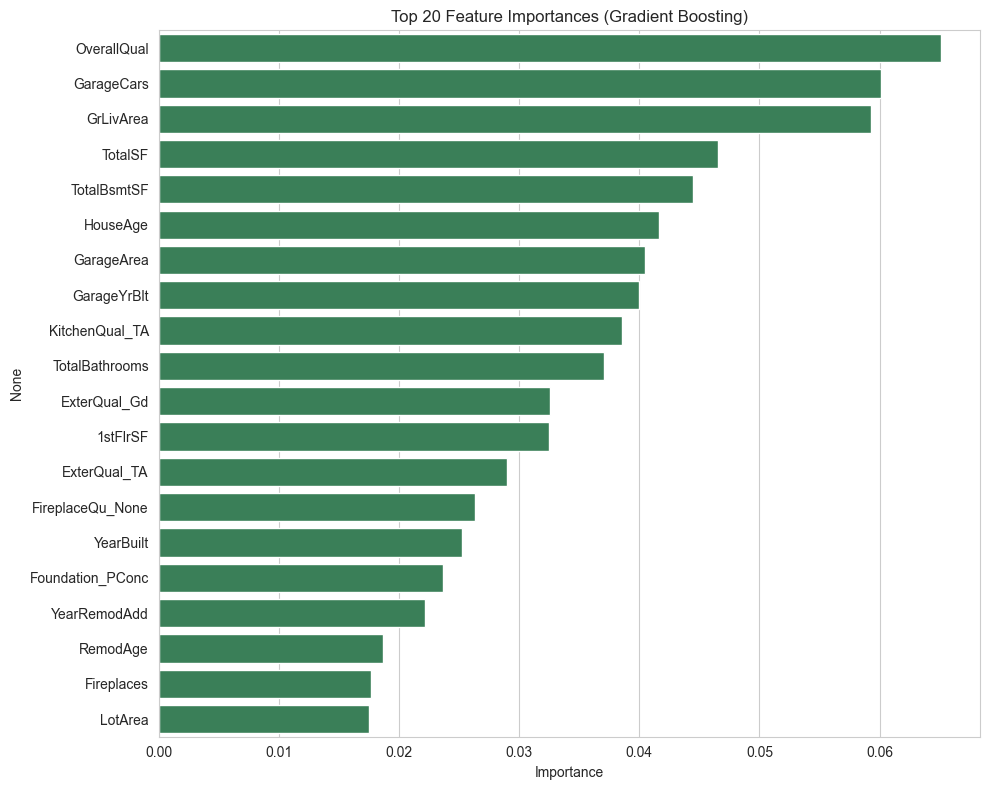

In [39]:
final_gbr.fit(X_train_full, y_train)
 
importances = pd.Series(final_gbr.feature_importances_, index=X_train_full.columns)
top_importances = importances.sort_values(ascending=False).head(20)
 
plt.figure(figsize=(10, 8))
sns.barplot(x=top_importances.values, y=top_importances.index, color="seagreen")
plt.title("Top 20 Feature Importances (Gradient Boosting)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [40]:
final_log_preds = stacked_model.predict(X_test_full_scaled)
final_preds = np.expm1(final_log_preds)  # inverse of log1p
 
submission = pd.DataFrame({
    "Id": test_ID,
    "SalePrice": final_preds
})
 
submission.to_csv("submission.csv", index=False)
submission.head()
 

,Id,SalePrice
0,1461,122449.568370
1,1462,156228.560922
2,1463,184694.641115
3,1464,199386.283002
4,1465,192352.267421


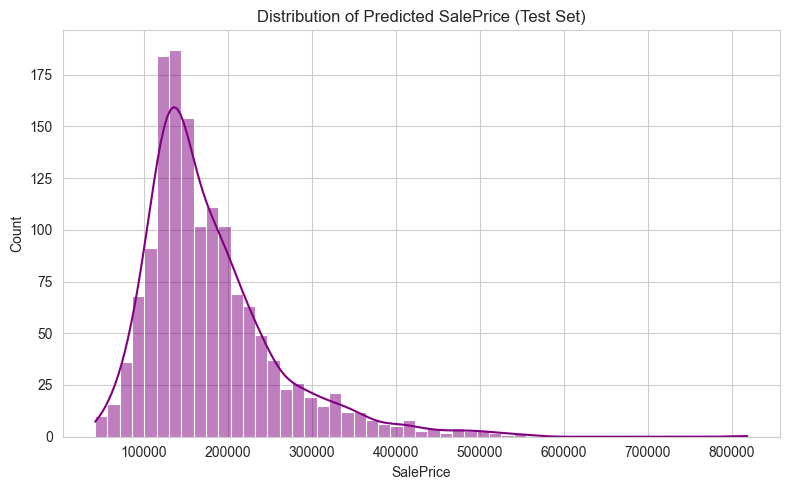

Saved predictions to submission.csv
count      1459.000000
mean     179170.891707
std       80224.392753
min       42251.354271
25%      126801.046823
50%      156495.078152
75%      210657.102125
max      818200.229795
Name: SalePrice, dtype: float64


In [41]:
plt.figure(figsize=(8, 5))
sns.histplot(submission["SalePrice"], kde=True, color="purple")
plt.title("Distribution of Predicted SalePrice (Test Set)")
plt.tight_layout()
plt.show()
 
print("Saved predictions to submission.csv")
print(submission["SalePrice"].describe())
 

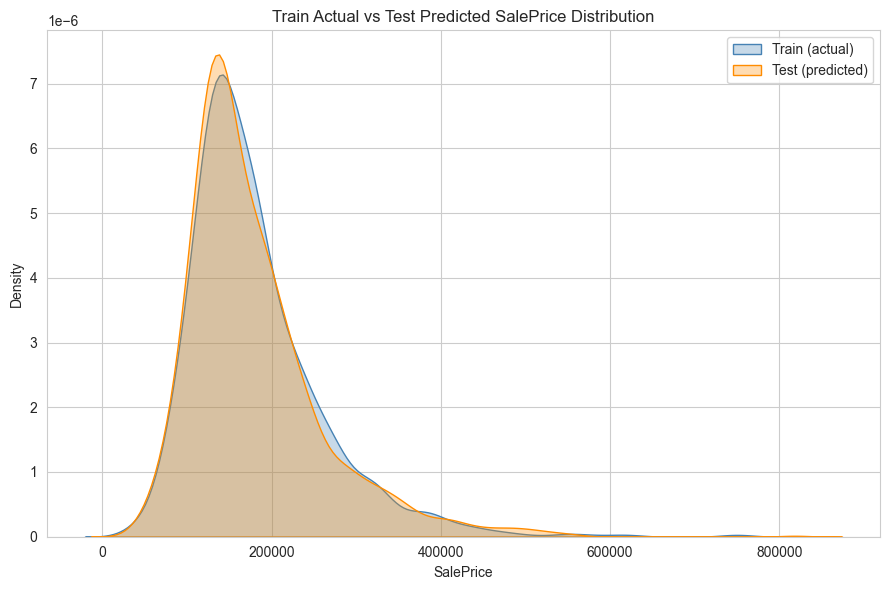

Train SalePrice describe():
count      1458.000000
mean     180932.919067
std       79495.055285
min       34900.000000
25%      129925.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [42]:
plt.figure(figsize=(9, 6))
sns.kdeplot(train["SalePrice"], label="Train (actual)", fill=True, alpha=0.3, color="steelblue")
sns.kdeplot(submission["SalePrice"], label="Test (predicted)", fill=True, alpha=0.3, color="darkorange")
plt.title("Train Actual vs Test Predicted SalePrice Distribution")
plt.xlabel("SalePrice")
plt.legend()
plt.tight_layout()
plt.show()

print("Train SalePrice describe():")
print(train["SalePrice"].describe())